In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np 

In [2]:
close_prices = pd.read_csv("/Users/alexzheng/Developer/GitHub/EC331-project/EMH/Data/Bitcoin_data_2024.csv",
                           index_col=0,
                           parse_dates=True)

close_prices['Returns%'] = np.log(close_prices['Close'] / close_prices['Close'].shift(1))*100
close_prices.dropna(inplace=True)

close_prices

,Open,High,Low,Close,VolumeBTC,VolumeUSD,Returns%
date,,,,,,,
2024-01-01 00:01:00,42268.0,42283.0,42268,42283,2.291939,96910.057583,0.035482
2024-01-01 00:02:00,42288.0,42298.0,42288,42298,1.569998,66407.775404,0.035469
2024-01-01 00:03:00,42297.0,42353.0,42297,42353,4.883858,206846.034909,0.129945
2024-01-01 00:04:00,42359.0,42375.0,42359,42375,5.742427,243335.353448,0.051931
2024-01-01 00:05:00,42379.0,42395.0,42369,42395,1.381973,58588.752966,0.047187
...,...,...,...,...,...,...,...
2024-12-31 23:55:00,93476.0,93476.0,93471,93471,0.179799,16805.981112,-0.023534
2024-12-31 23:56:00,93469.0,93469.0,93469,93469,0.021400,2000.236600,-0.002140
2024-12-31 23:57:00,93462.0,93462.0,93413,93427,0.034750,3246.554616,-0.044945


In [3]:
# Import fear and greed data 
fear_n_greed = pd.read_csv("/Users/alexzheng/Developer/GitHub/EC331-project/EMH/Data/fear_n_greed_2024.csv",
                               index_col=0,
                               parse_dates=True)
fear_n_greed.rename(columns = {'value': 'fear_n_greed_index'}, inplace = True)
fear_n_greed = fear_n_greed.drop(columns = ['classification'])
fear_n_greed

,fear_n_greed_index
date,
2024-01-01,65
2024-01-02,71
2024-01-03,70
2024-01-04,68
2024-01-05,72
...,...
2024-12-27,74
2024-12-28,72
2024-12-29,73


In [4]:
# Merge price and sentiment data
df = pd.merge(close_prices, fear_n_greed, on='date', how='outer')

# Select dates
df = df.loc['2024-01-01 00:00:00':'2024-12-31 23:59:00']

# Display data
df

,Open,High,Low,Close,VolumeBTC,VolumeUSD,Returns%,fear_n_greed_index
date,,,,,,,,
2024-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,65.0
2024-01-01 00:01:00,42268.0,42283.0,42268.0,42283.0,2.291939,96910.057583,0.035482,NaN
2024-01-01 00:02:00,42288.0,42298.0,42288.0,42298.0,1.569998,66407.775404,0.035469,NaN
2024-01-01 00:03:00,42297.0,42353.0,42297.0,42353.0,4.883858,206846.034909,0.129945,NaN
2024-01-01 00:04:00,42359.0,42375.0,42359.0,42375.0,5.742427,243335.353448,0.051931,NaN
...,...,...,...,...,...,...,...,...
2024-12-31 23:55:00,93476.0,93476.0,93471.0,93471.0,0.179799,16805.981112,-0.023534,NaN
2024-12-31 23:56:00,93469.0,93469.0,93469.0,93469.0,0.021400,2000.236600,-0.002140,NaN
2024-12-31 23:57:00,93462.0,93462.0,93413.0,93427.0,0.034750,3246.554616,-0.044945,NaN


In [5]:
df.count()

Open                  509363
High                  509363
Low                   509363
Close                 509363
VolumeBTC             509363
VolumeUSD             509363
Returns%              509363
fear_n_greed_index       365
dtype: int64

In [6]:
print(f"The number of data missing: \n{df.isnull().sum()}")

The number of data missing: 
Open                      39
High                      39
Low                       39
Close                     39
VolumeBTC                 39
VolumeUSD                 39
Returns%                  39
fear_n_greed_index    509037
dtype: int64


In [7]:
# Forward-fill missing sentiment scores
df = df.ffill()

# Drop rows with missing data
df = df.dropna()

In [8]:
df

,Open,High,Low,Close,VolumeBTC,VolumeUSD,Returns%,fear_n_greed_index
date,,,,,,,,
2024-01-01 00:01:00,42268.0,42283.0,42268.0,42283.0,2.291939,96910.057583,0.035482,65.0
2024-01-01 00:02:00,42288.0,42298.0,42288.0,42298.0,1.569998,66407.775404,0.035469,65.0
2024-01-01 00:03:00,42297.0,42353.0,42297.0,42353.0,4.883858,206846.034909,0.129945,65.0
2024-01-01 00:04:00,42359.0,42375.0,42359.0,42375.0,5.742427,243335.353448,0.051931,65.0
2024-01-01 00:05:00,42379.0,42395.0,42369.0,42395.0,1.381973,58588.752966,0.047187,65.0
...,...,...,...,...,...,...,...,...
2024-12-31 23:55:00,93476.0,93476.0,93471.0,93471.0,0.179799,16805.981112,-0.023534,64.0
2024-12-31 23:56:00,93469.0,93469.0,93469.0,93469.0,0.021400,2000.236600,-0.002140,64.0
2024-12-31 23:57:00,93462.0,93462.0,93413.0,93427.0,0.034750,3246.554616,-0.044945,64.0


In [9]:
df.count()

Open                  509401
High                  509401
Low                   509401
Close                 509401
VolumeBTC             509401
VolumeUSD             509401
Returns%              509401
fear_n_greed_index    509401
dtype: int64

In [10]:
df.isna().sum()

Open                  0
High                  0
Low                   0
Close                 0
VolumeBTC             0
VolumeUSD             0
Returns%              0
fear_n_greed_index    0
dtype: int64

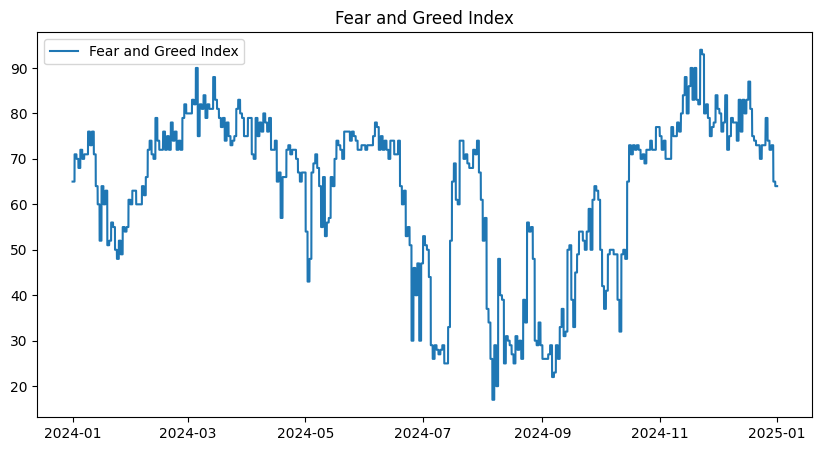

In [11]:
# Plot fear_n_greed_index
plt.figure(figsize=(10, 5))
plt.plot(df['fear_n_greed_index'], label='Fear and Greed Index')
plt.title('Fear and Greed Index')
plt.legend(loc='best')
plt.show()

In [12]:
df.to_csv("/Users/alexzheng/Developer/GitHub/EC331-project/EMH/Data/Bitcoin_data_with_sentiment.csv")